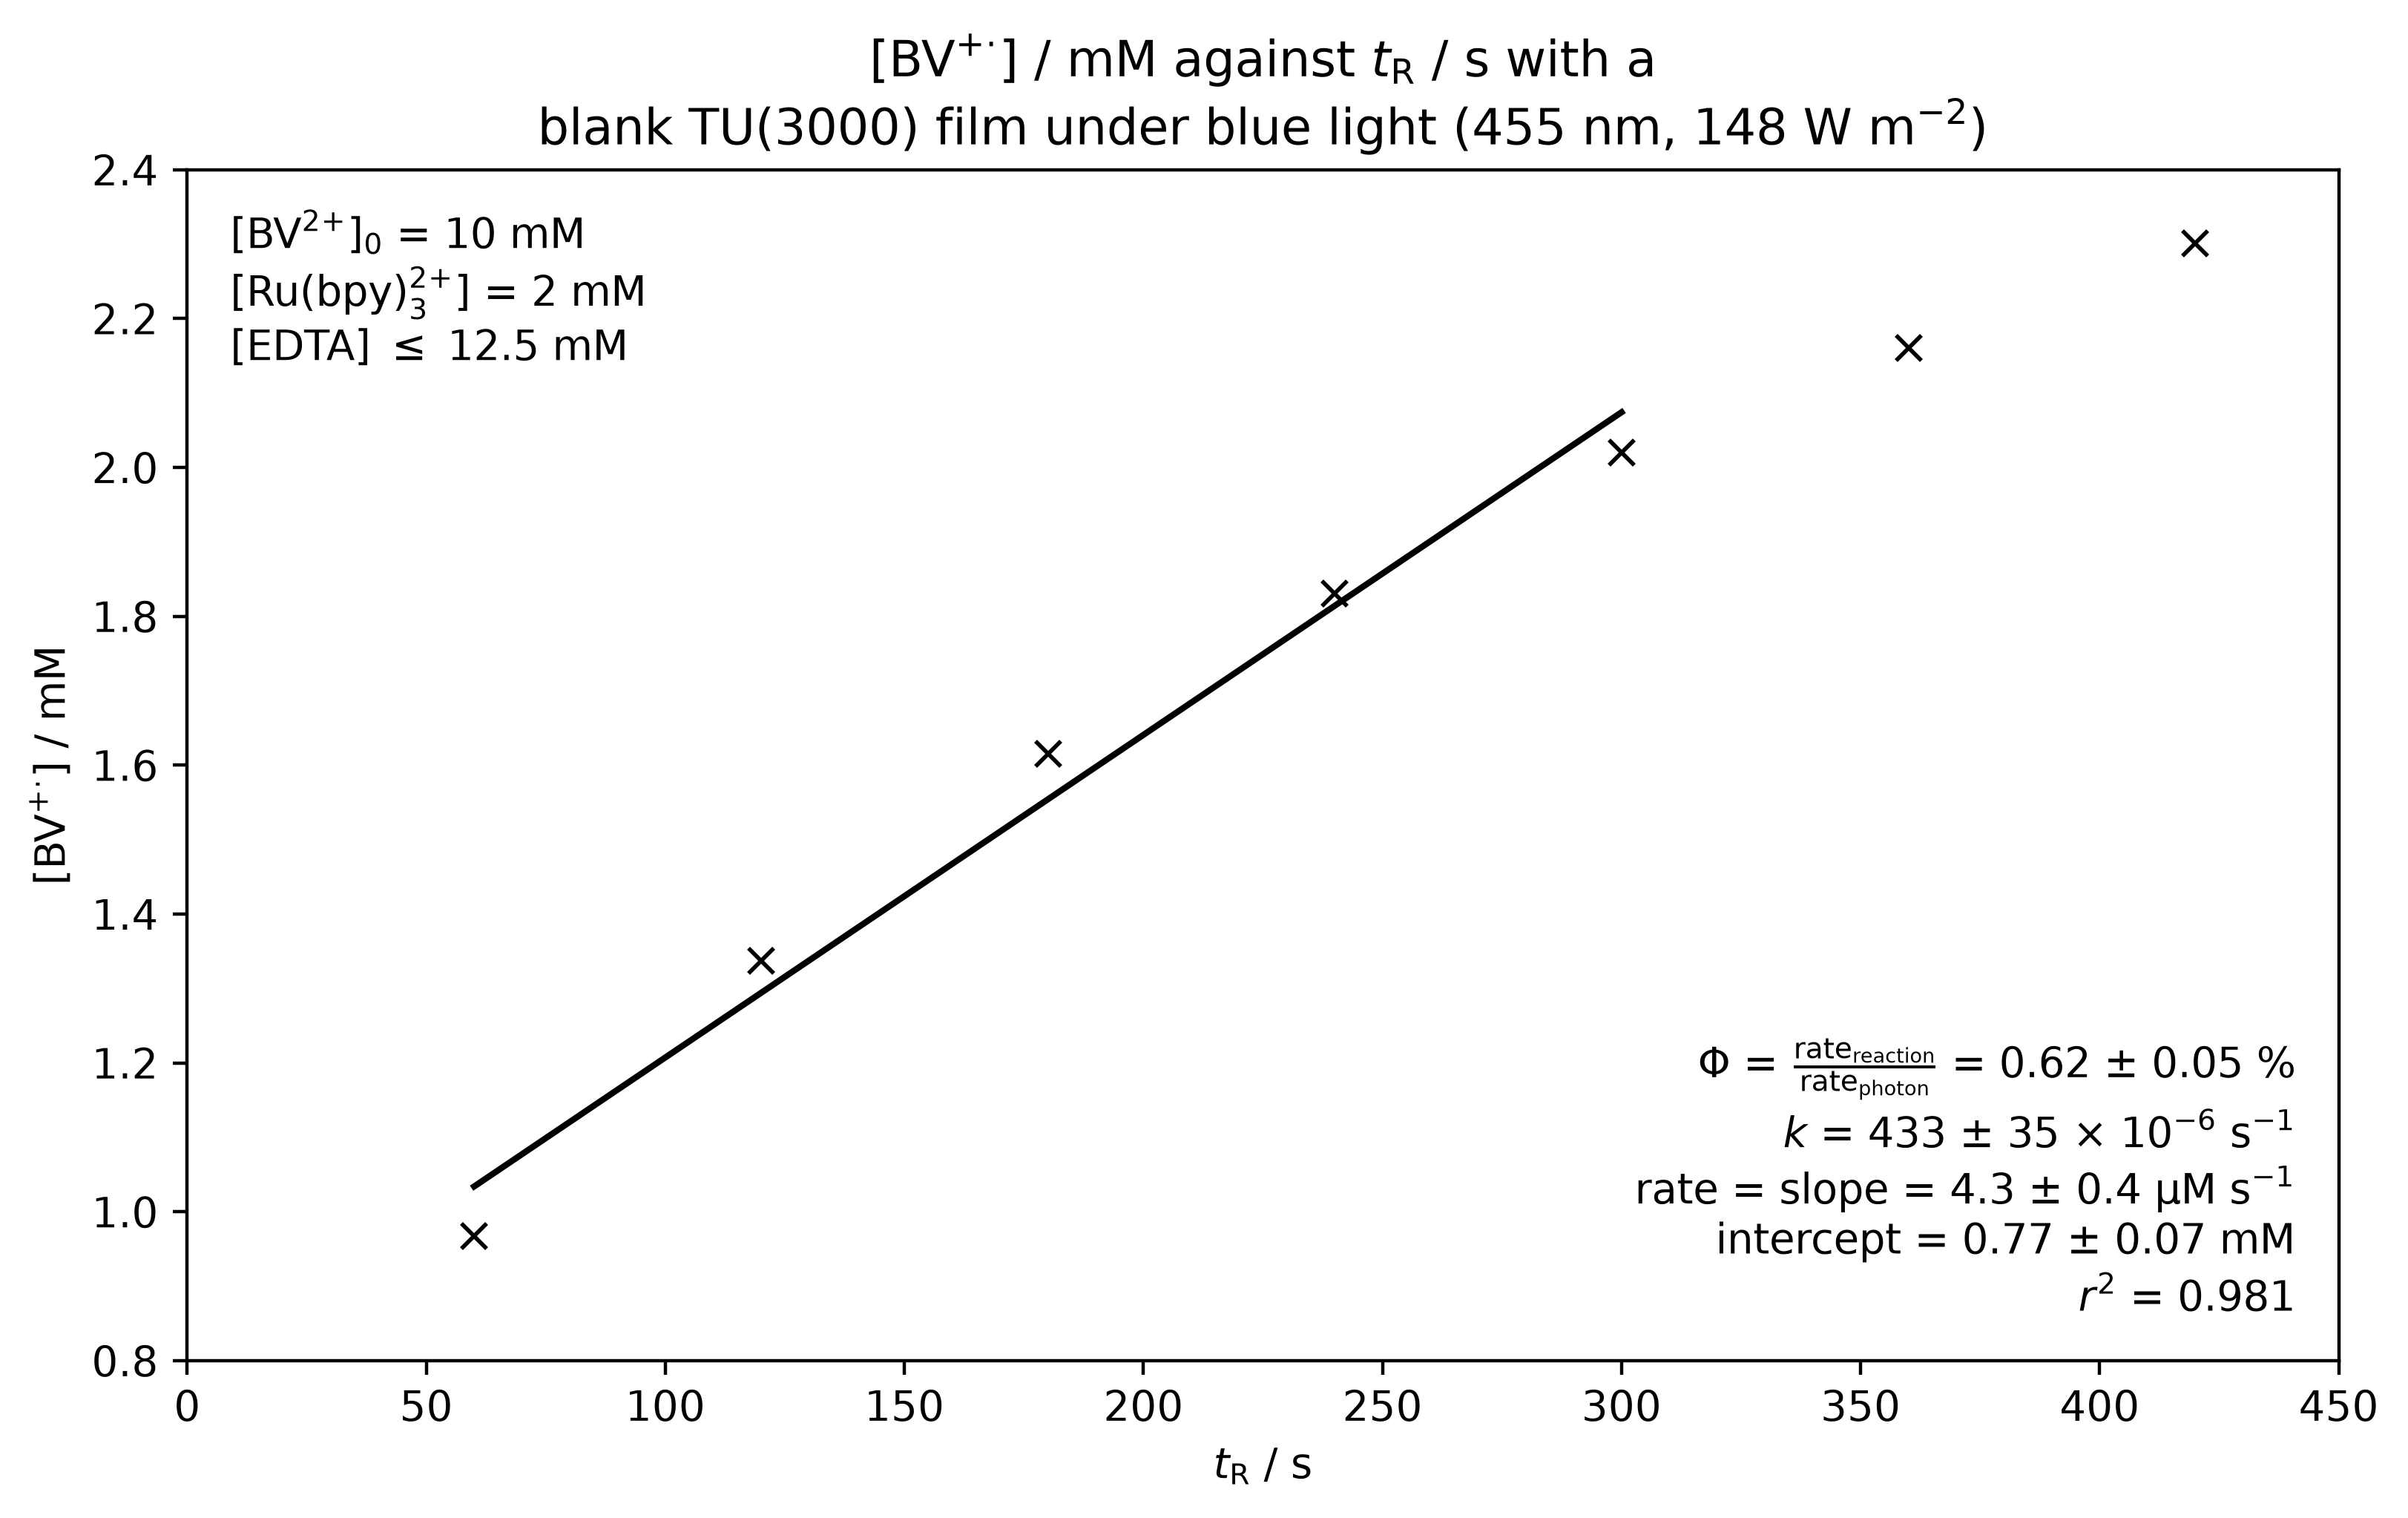

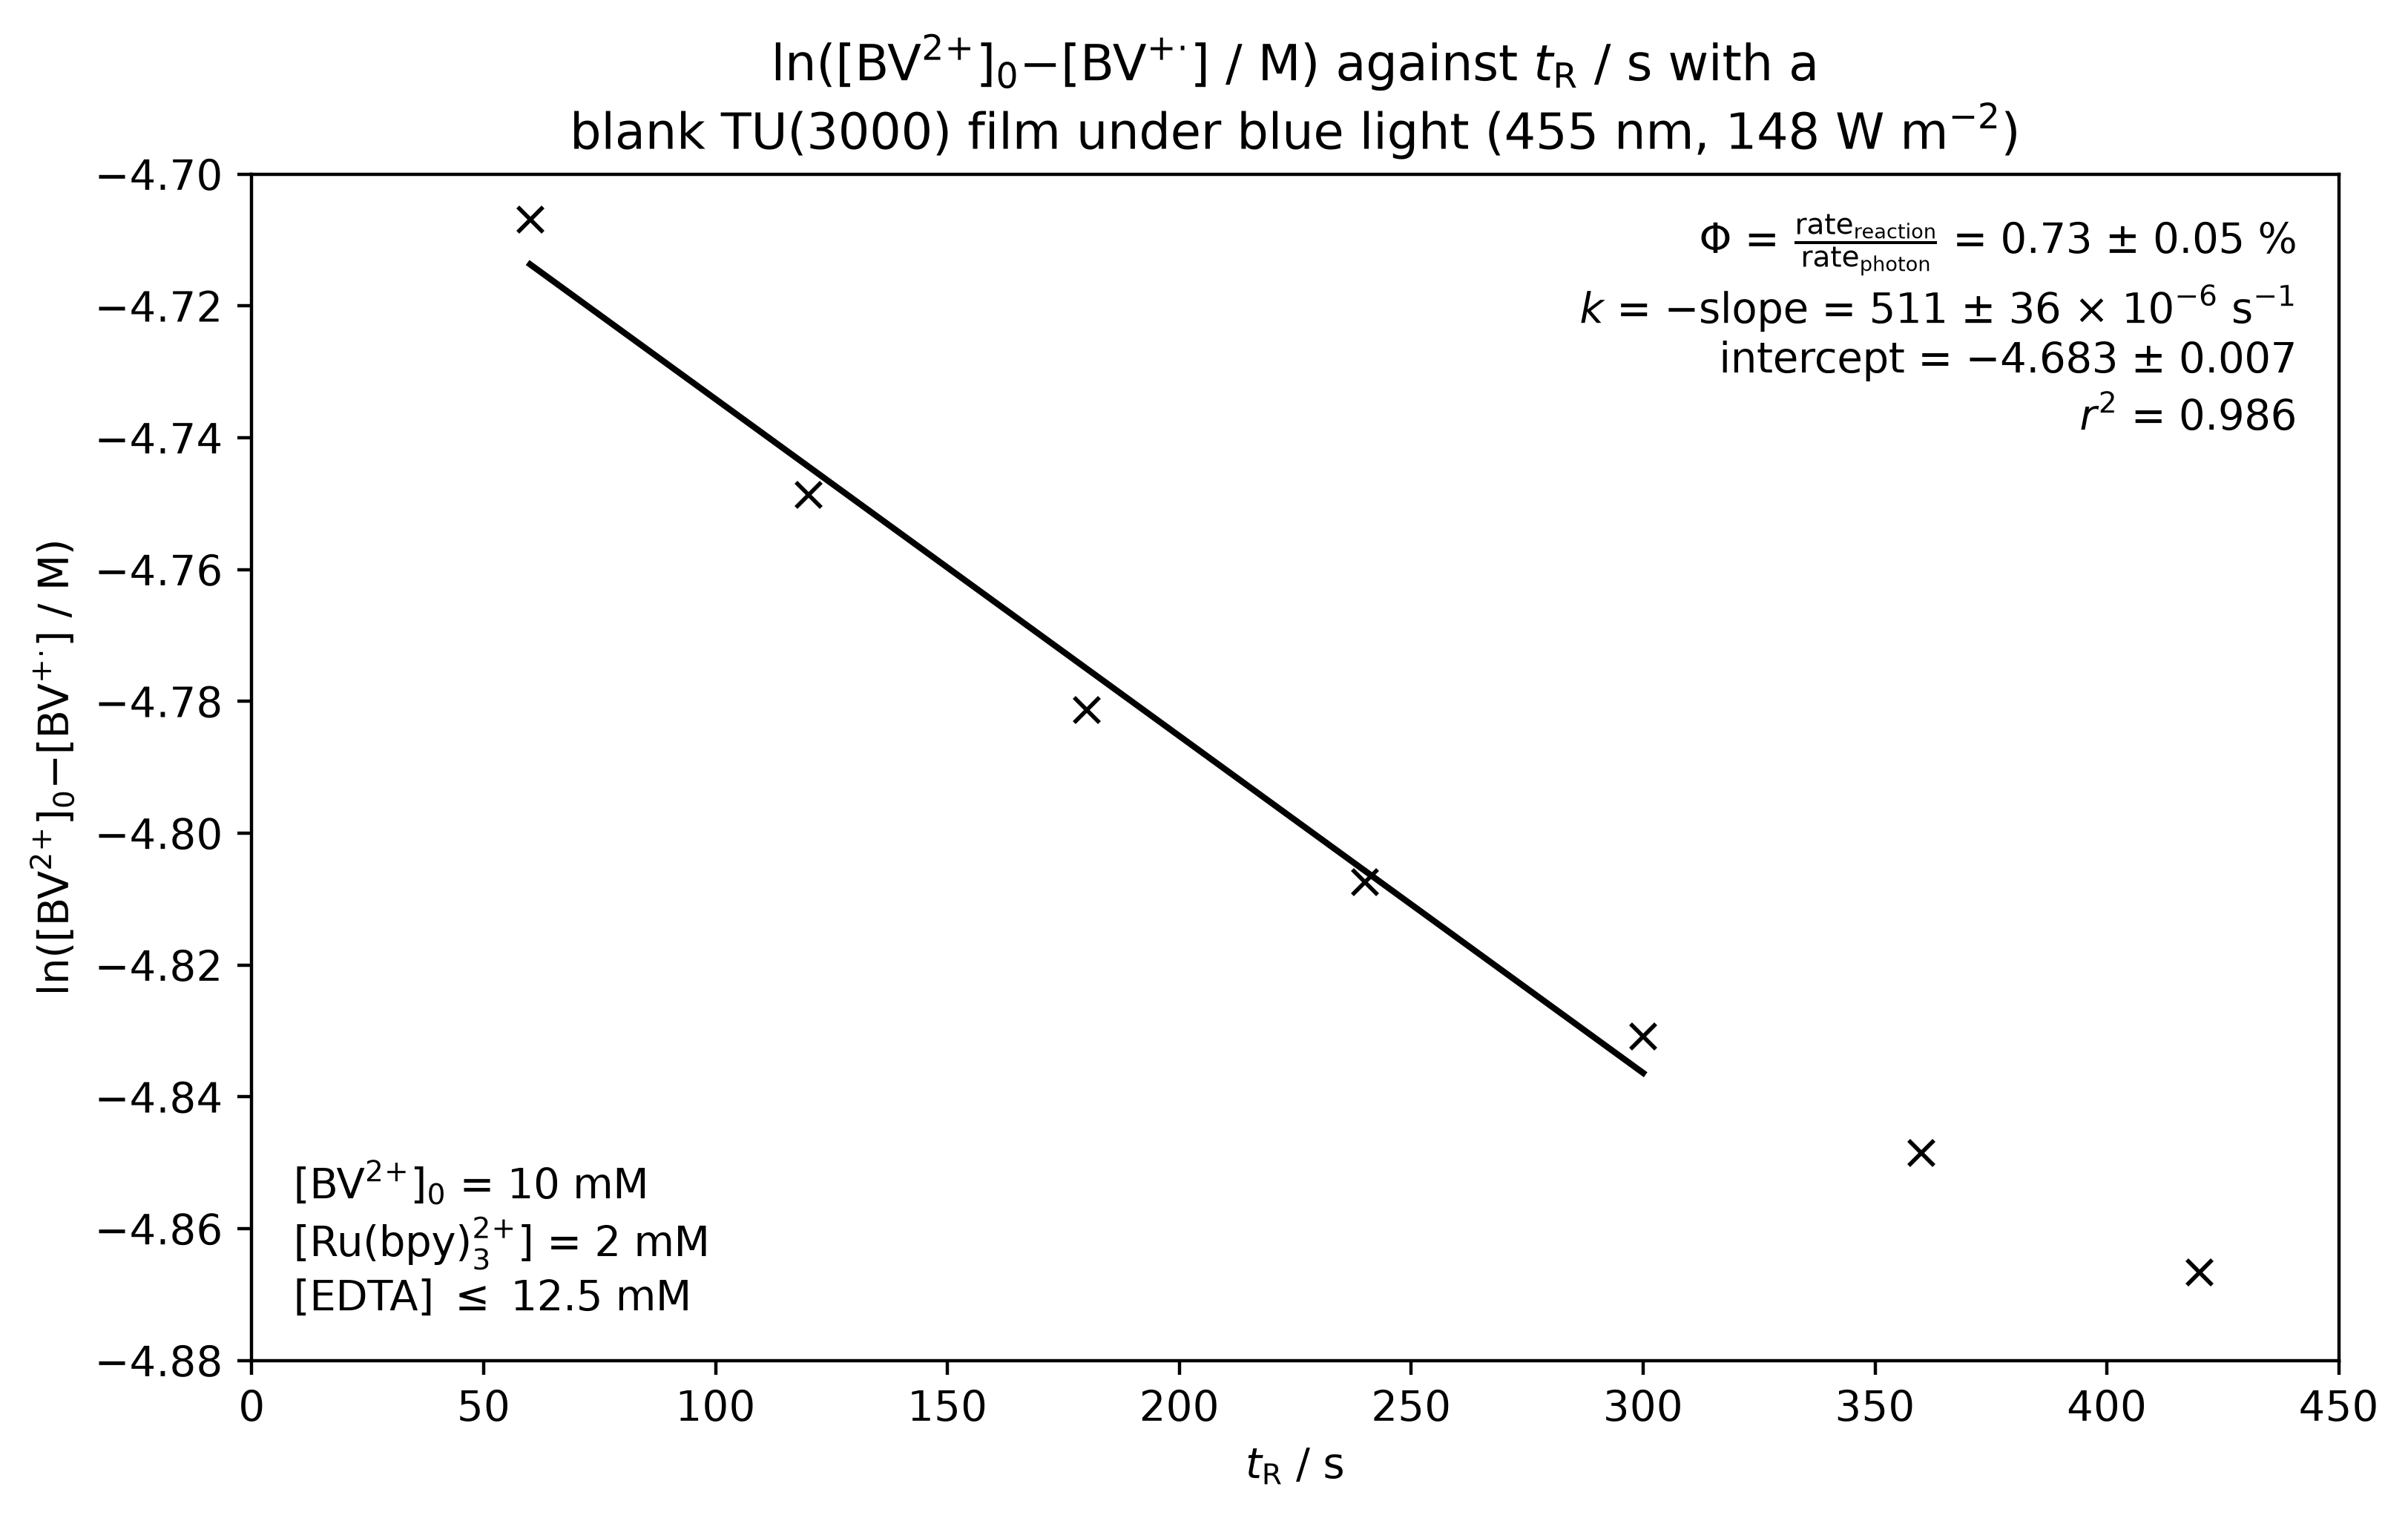

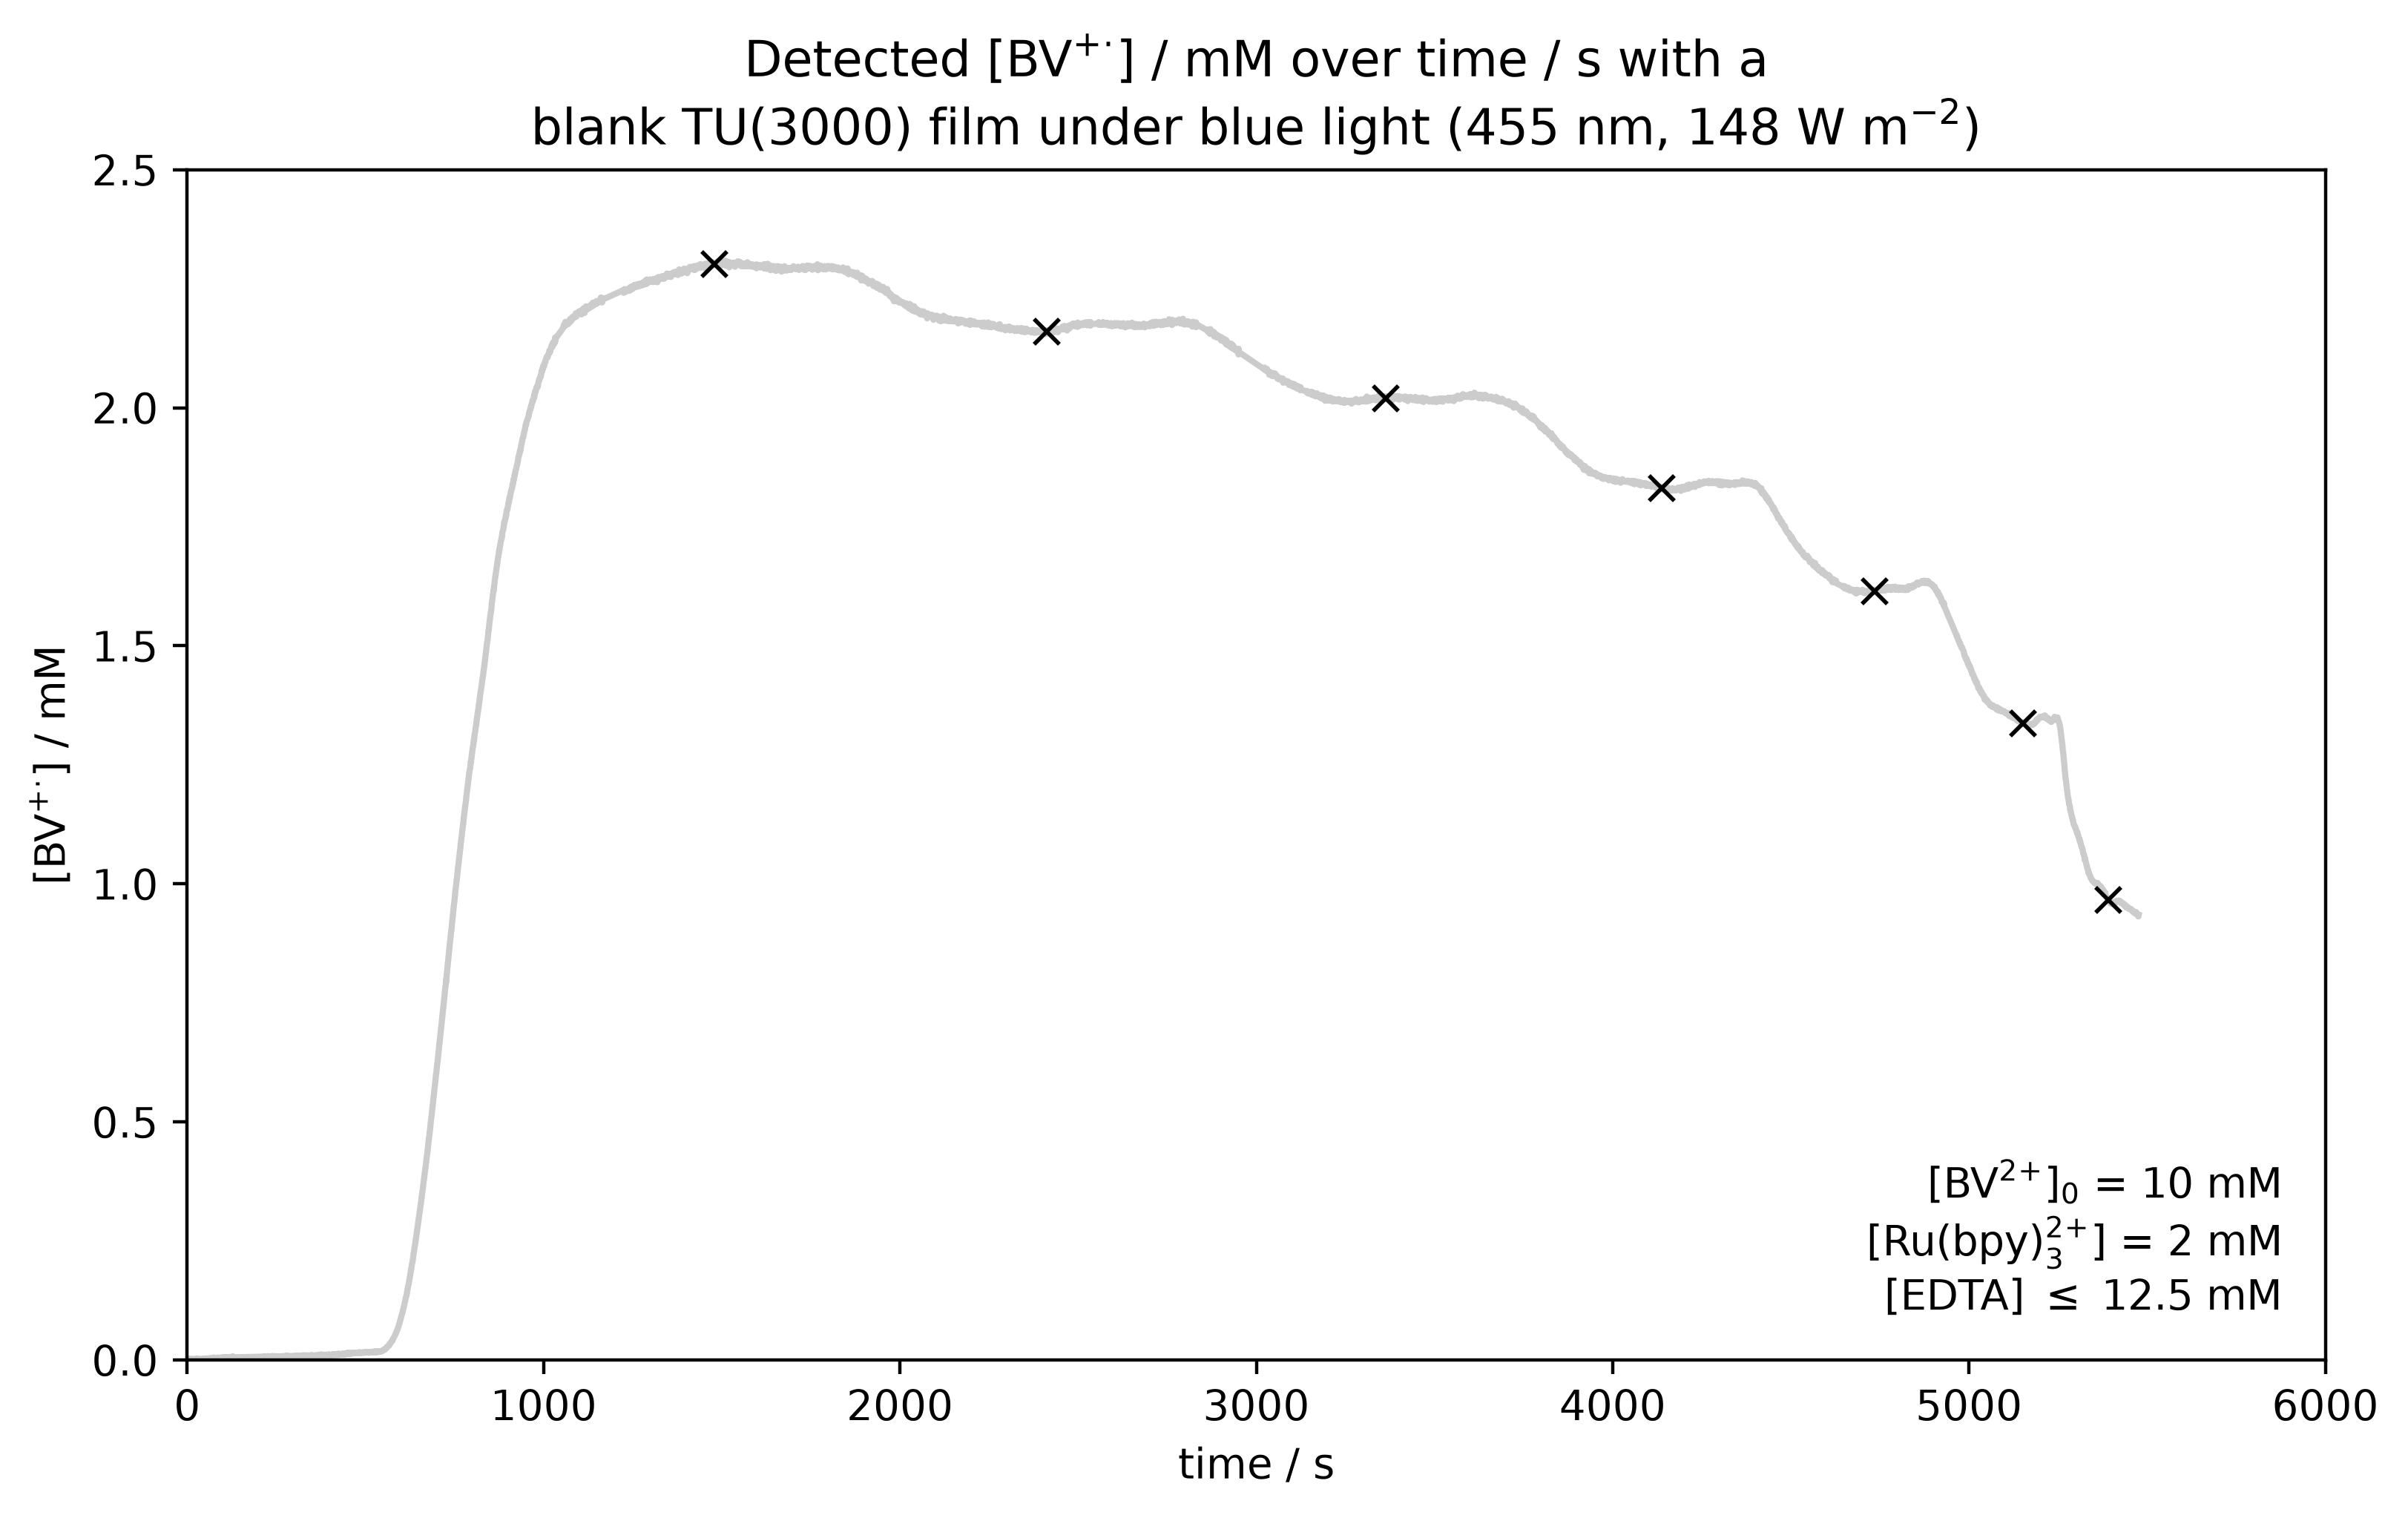

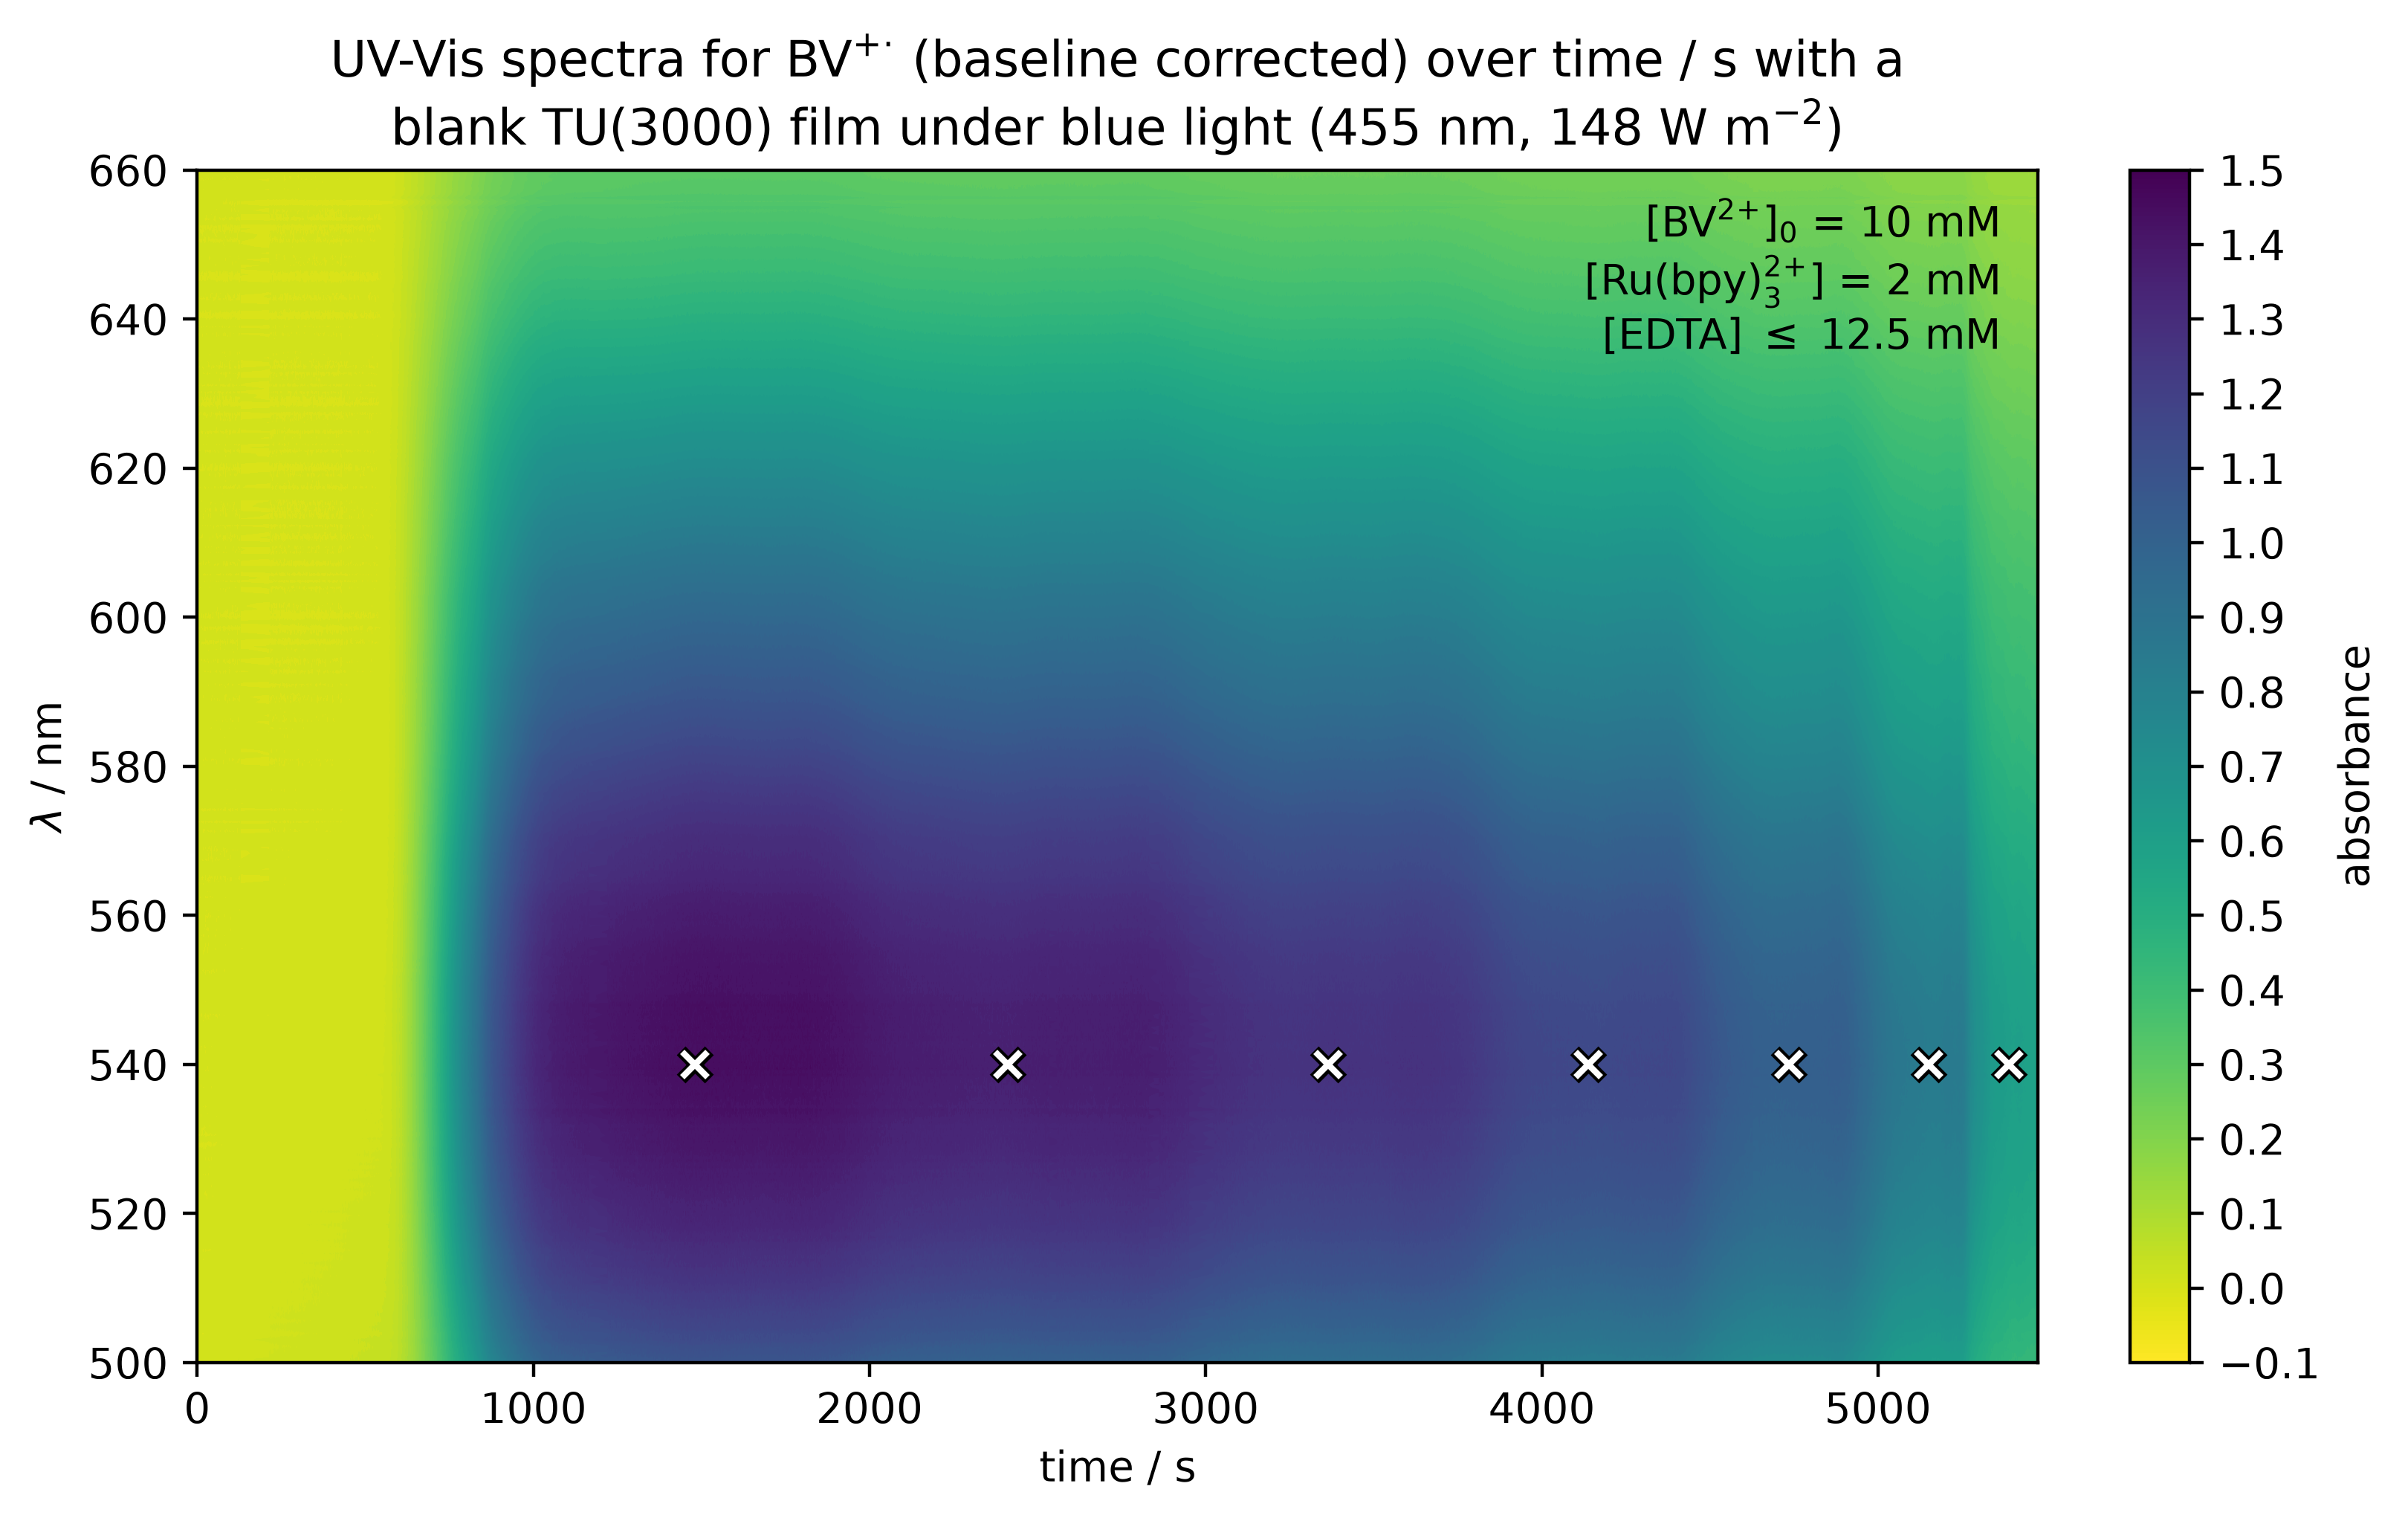

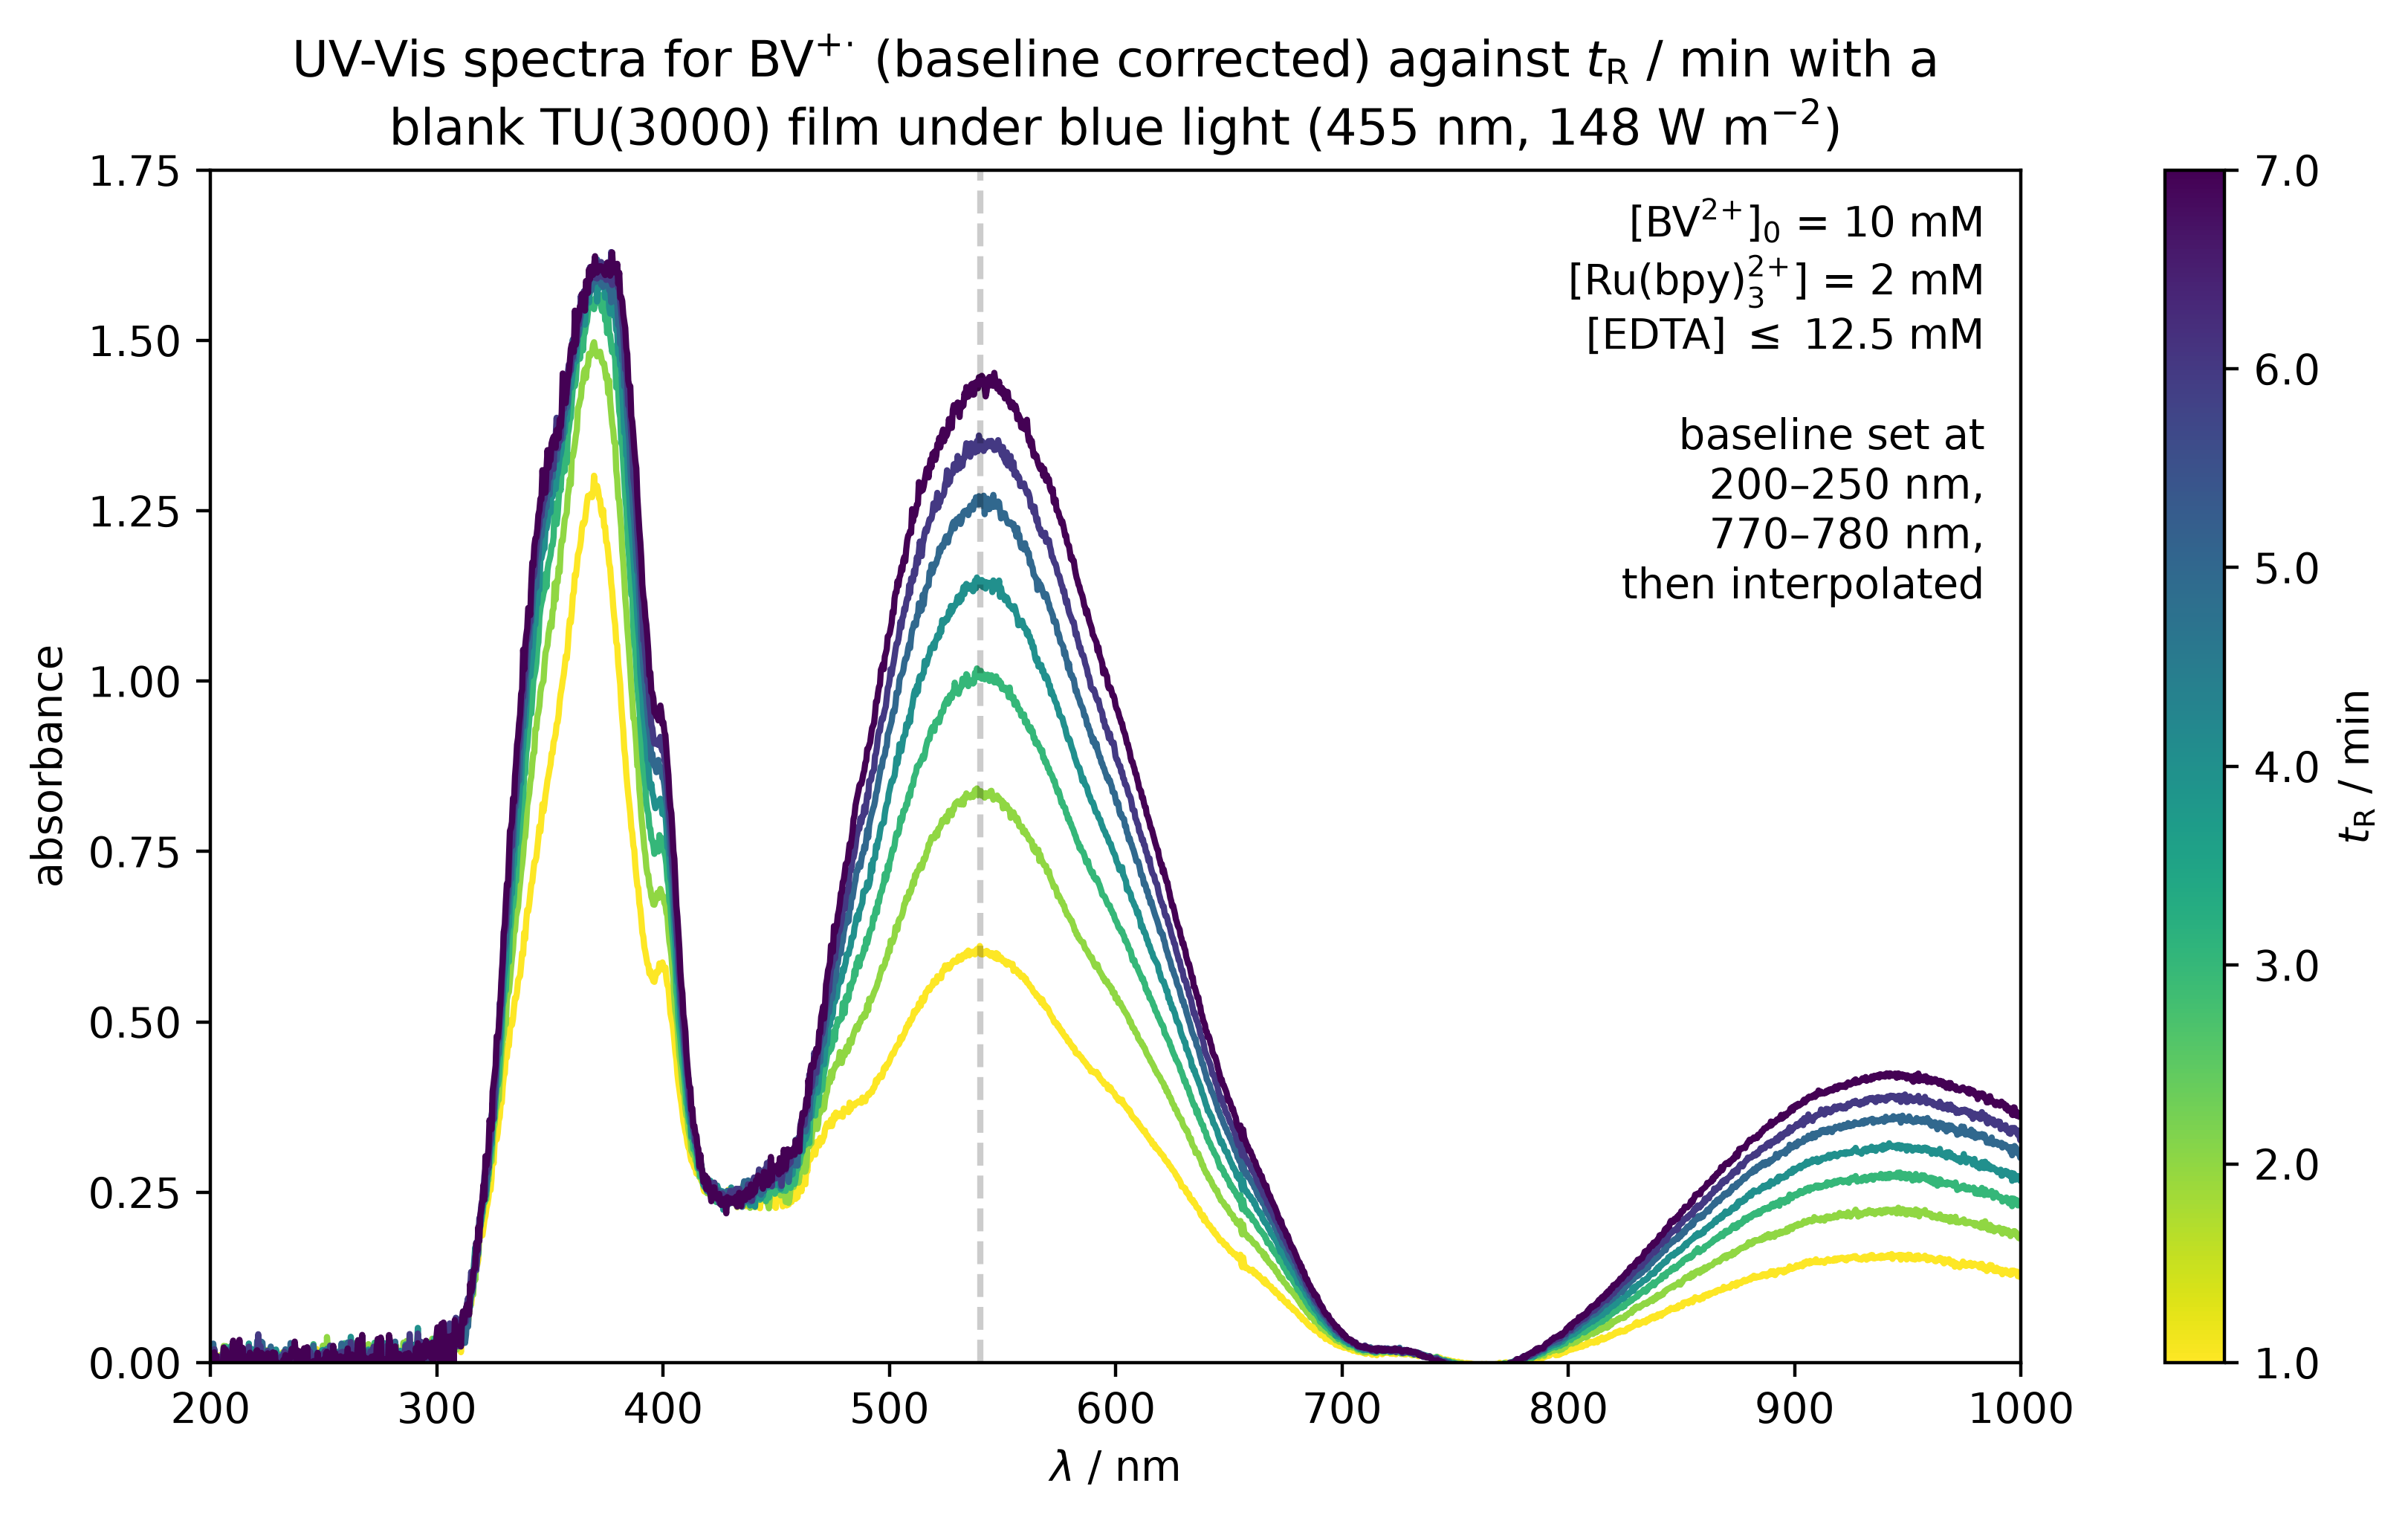

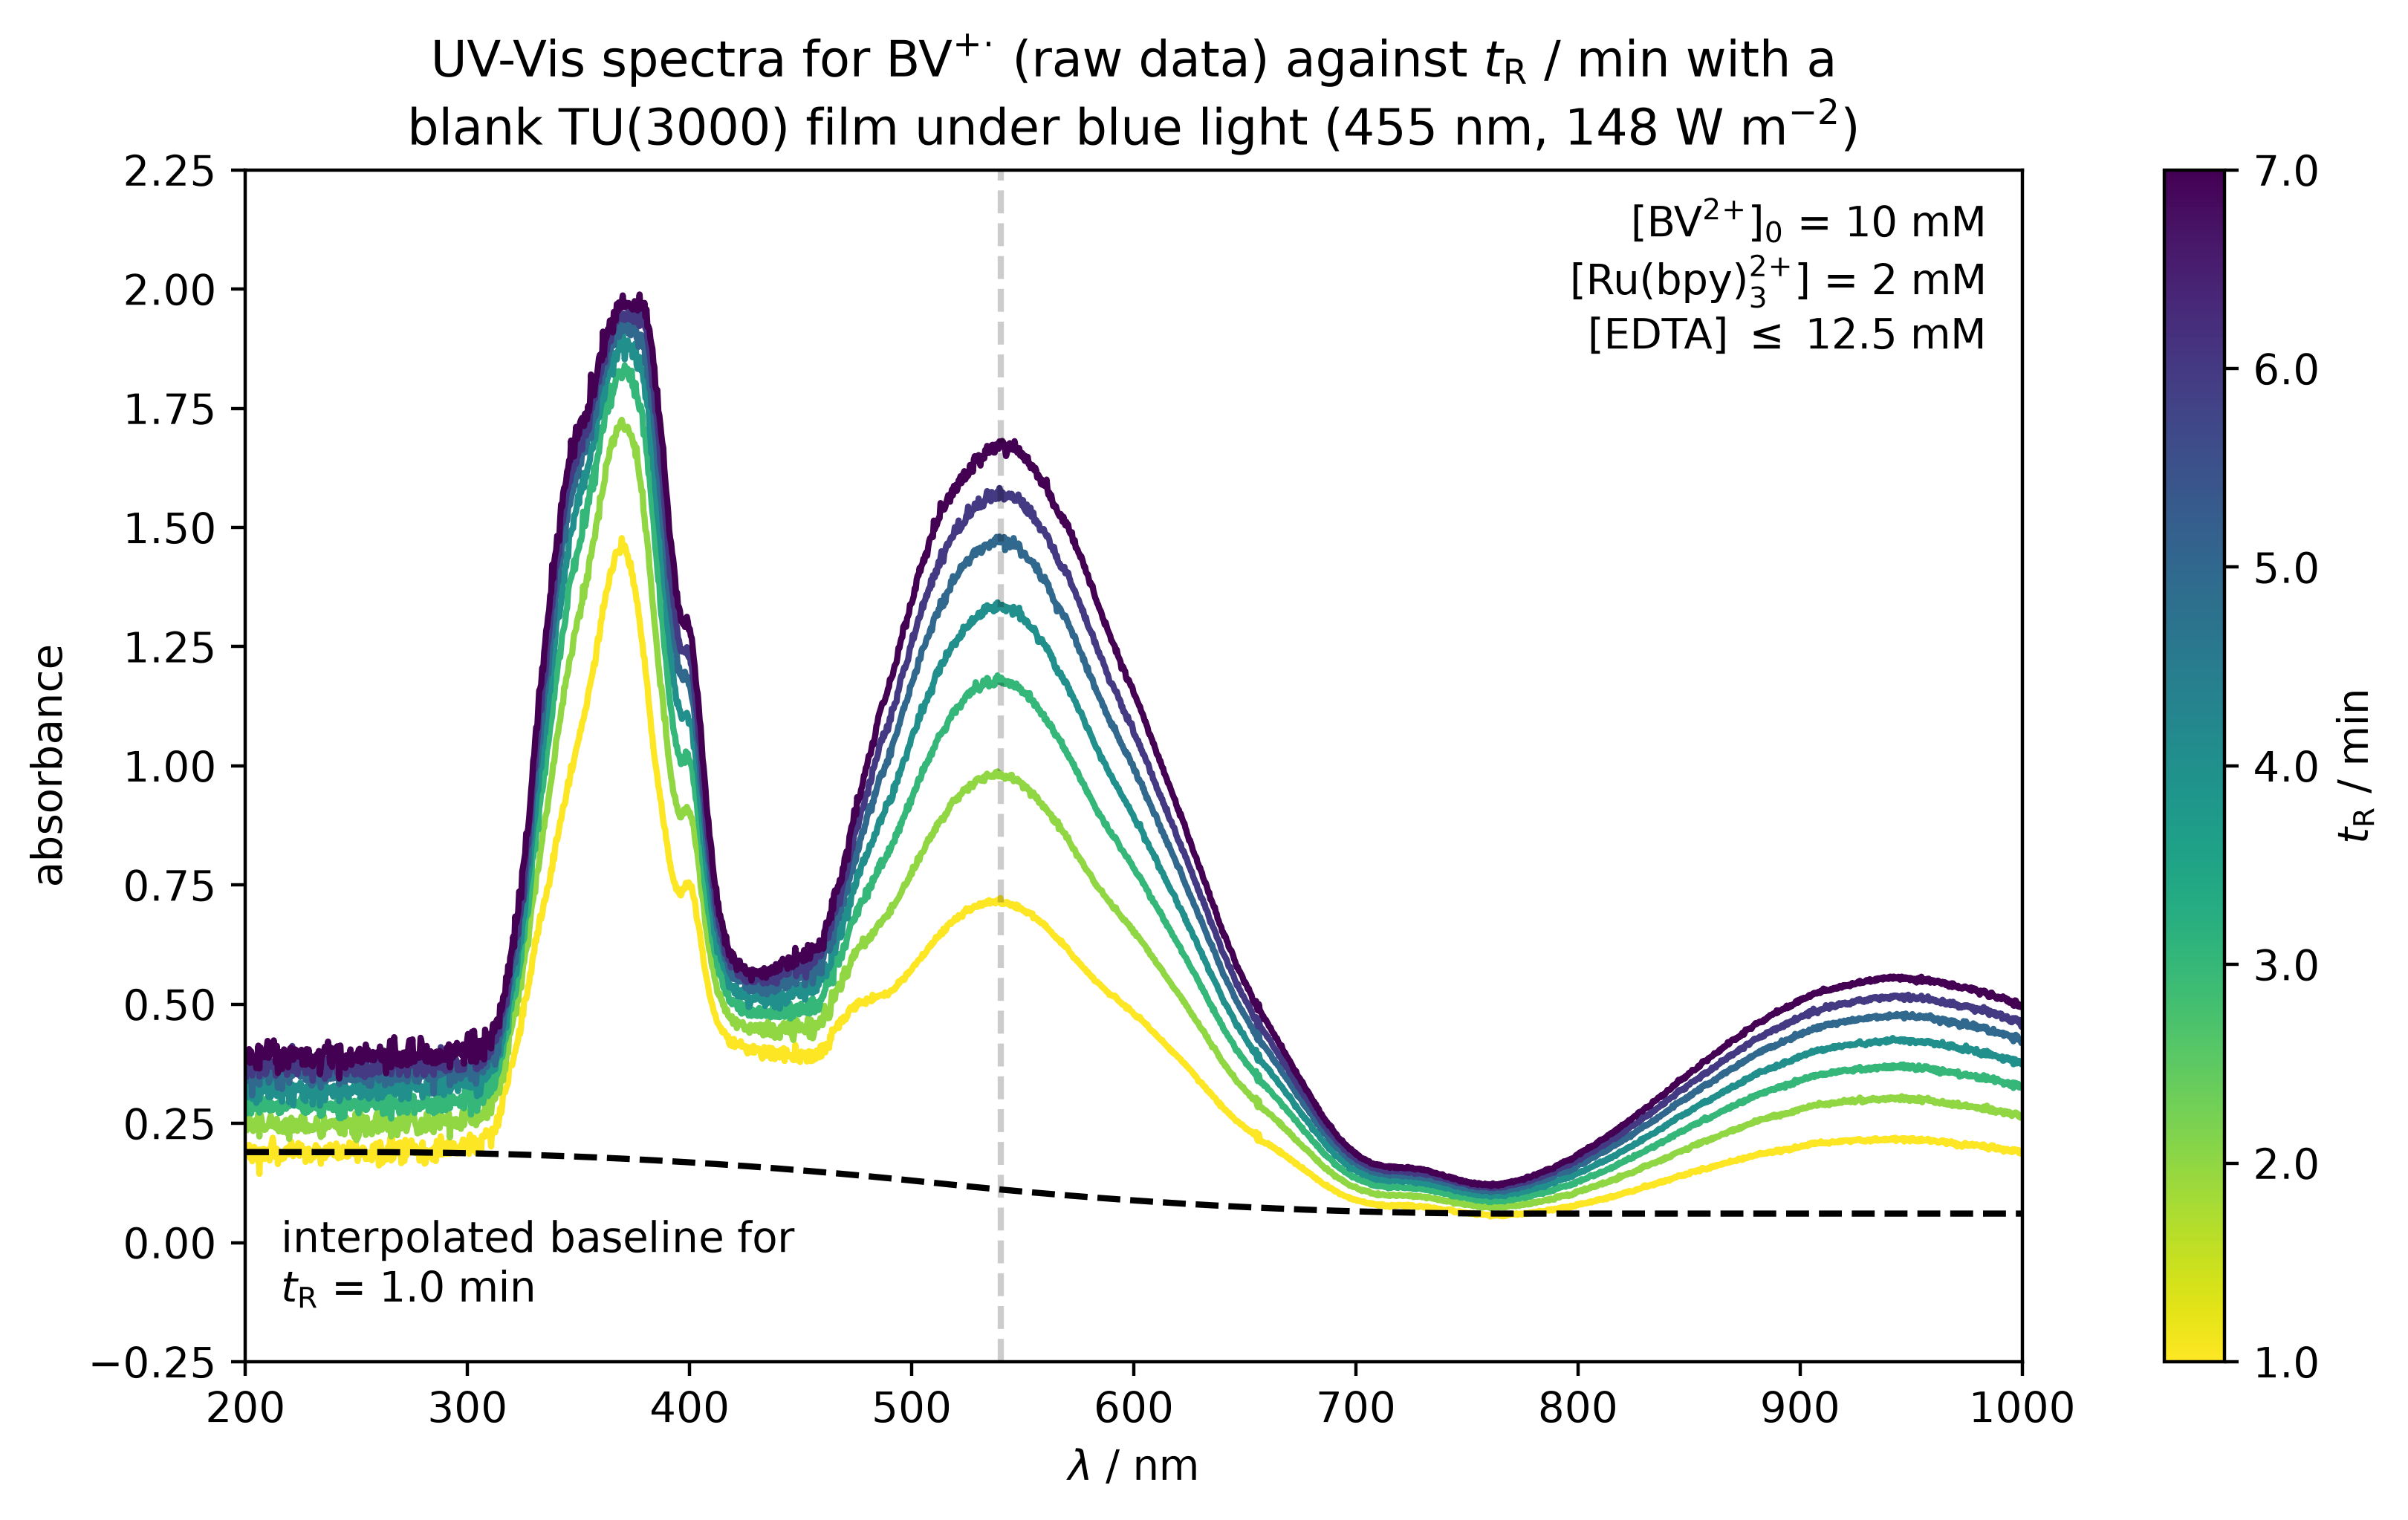

In [1]:
from lsmr_photocatalysis import ContinuousFlow, FLOW_PARAMS, X
import numpy as np

"""
Continuous flow with reaction/LED/film and UV-Vis at opposite ends of a single 250 ul reactor chamber.
Flow rate changes according to flow scheme at different time points to change residence time tR.
Blue 455 nm irradiation at 10.5 mW.

V([Ru(bpy)3]2+, 12 mM, pH 7 buffer) = 500 ul (2 mM)
V(BV2+, 30 mM, pH 7 buffer) = 1000 ul (10 mM)
V(EDTA, <25 mM saturated, pH 7 buffer) = 1500 ul (<12.5 mM)
"""

data = '260807_Rubpy_BV_EDTA_TU(3000)_Blank_Blue_Flow_Scattering_Test' # data folder name

tRs = np.arange(7*60, 60-1, -60) # residence times/s for 7-1 min (i.e. reversed) in 1 min intervals
points = ContinuousFlow.recpoints(tRs, *FLOW_PARAMS['250ul']) # time/s points to record absorbances
points[0] += 200 # add 200 s to the first record point
start = '16-18-00-000'

c0 = 10e-3 # initial BV2+ concentration
details = f'{X['RU']} = 2 mM\n[EDTA] $\\leq$ 12.5 mM' # concentrations of other reagents

x = 'BVrubpy'
film = 'blank TU(3000)' # 30/01/2024
light = 'blue'
wavelength = 455e-9 # m
power = 10.5e-3 # W

expt = ContinuousFlow(data, tRs, points, start, c0, details, x, film, light, wavelength, power, reverse=True)
expt.concvstimeplot(r2threshold=0.98)
expt.concvstimeplot(ln=True, r2threshold=0.98)
expt.detectorconcplot()
expt.detectorspectrumplot()
expt.spectrumvstimeplot()